<h2>Data Analytics- notebook, Compost coders</h2>

<h4><b>Dataset name: Short description</b></h4>

Dataset analysis about Lapin AMK composters

<h4><b>Data source (url):</b></h4>

https://kuituhamppu.frostbit.fi/composting/measurements

<h4><b>Data format:</b></h4>

Describe file structure here.

<h4><b>Data description, features and limitations:</b></h4>

Write needed descriptions here.

<h3><b>Code: importing modules, custom functions and loading the data</b></h3>

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [49]:
# Load the dataset
df = pd.read_csv('../../data/combined_compost_measurements.csv')

<h3><b>Code: Data clean-up procedure</b></h3>

In [50]:
df.columns

Index(['Day', 'Compost 1-Inside-Heating - kWh', 'Compost 1-Inside-Heating - w',
       'Compost 1-Lower-Moisture', 'Compost 1-Lower-Temperature',
       'Compost 1-Middle-Moisture', 'Compost 1-Middle-Temperature',
       'Compost 1-Upper-Moisture', 'Compost 1-Upper-Temperature',
       'Compost 2-Inside-Heating - kWh', 'Compost 2-Inside-Heating - w',
       'Compost 2-Lower-Moisture', 'Compost 2-Lower-Temperature',
       'Compost 2-Middle-Moisture', 'Compost 2-Middle-Temperature',
       'Compost 2-Upper-Moisture', 'Compost 2-Upper-Temperature',
       'Growing-18E0-Moisture', 'Growing-18E0-Temperature',
       'Growing-4B21-Moisture', 'Growing-4B21-Temperature',
       'Growing-5D20-Moisture', 'Growing-5D20-Temperature',
       'Growing-E43B-Moisture', 'Growing-E43B-Temperature',
       'Growing-R9A5E-Moisture', 'Growing-R9A5E-Temperature',
       'Growing-Sensor 01-Moisture', 'Growing-Sensor 02-Moisture',
       'Growing-Sensor 03-Moisture', 'Growing-Sensor 04-Moisture',
       'Gro

In [51]:
# Convert 'Day' column to datetime format
df['Day'] = pd.to_datetime(df['Day'])

In [52]:
# Drop Growing experiment columns and kWh columns
df.drop(df.filter(like="Growing").columns, axis=1, inplace=True)
df.drop(["Compost 1-Inside-Heating - kWh", "Compost 2-Inside-Heating - kWh"], axis=1, inplace=True)

In [53]:
# Shorten string names in columns for easier handling
df.columns = df.columns.str.replace('Compost 1-', 'C1_')
df.columns = df.columns.str.replace('Compost 2-', 'C2_')
df.columns = df.columns.str.replace('Outside-Outside-', 'Out_')
df.columns = df.columns.str.replace('Inside', 'Inside')
df.columns = df.columns.str.replace('Shed-Shed-', 'shed_')
df.columns = df.columns.str.replace('-', '_')
df.columns = df.columns.str.replace('Upper', 'Up')
df.columns = df.columns.str.replace('Lower', 'Low')
df.columns = df.columns.str.replace('Middle', 'Mid')
df.columns = df.columns.str.replace('Temperature', 'T')
df.columns = df.columns.str.replace('Moisture', 'M')
df.columns = df.columns.str.replace('Heating', 'heat')
df.columns = df.columns.str.replace(' ', '')


In [54]:
df = df[df['Day'] < '2025-10-01']

In [55]:
df.columns

Index(['Day', 'C1_Inside_heat_w', 'C1_Low_M', 'C1_Low_T', 'C1_Mid_M',
       'C1_Mid_T', 'C1_Up_M', 'C1_Up_T', 'C2_Inside_heat_w', 'C2_Low_M',
       'C2_Low_T', 'C2_Mid_M', 'C2_Mid_T', 'C2_Up_M', 'C2_Up_T', 'Out_M',
       'Out_T', 'shed_M', 'shed_T'],
      dtype='str')

<h3><b>Code: Data analysis</b></h3>

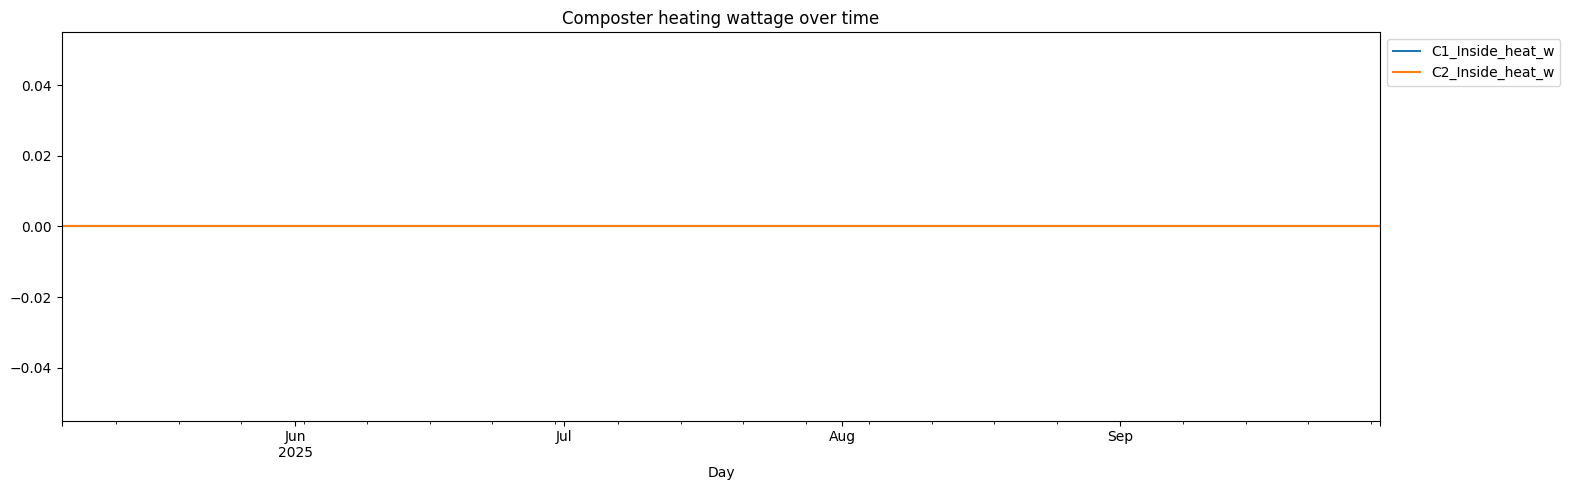

In [56]:
cols = [col for col in df.columns if col.startswith('') and col.endswith('w')]

df.set_index('Day')[cols].plot(figsize=(14, 5), title='Composter heating wattage over time')
plt.tight_layout()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

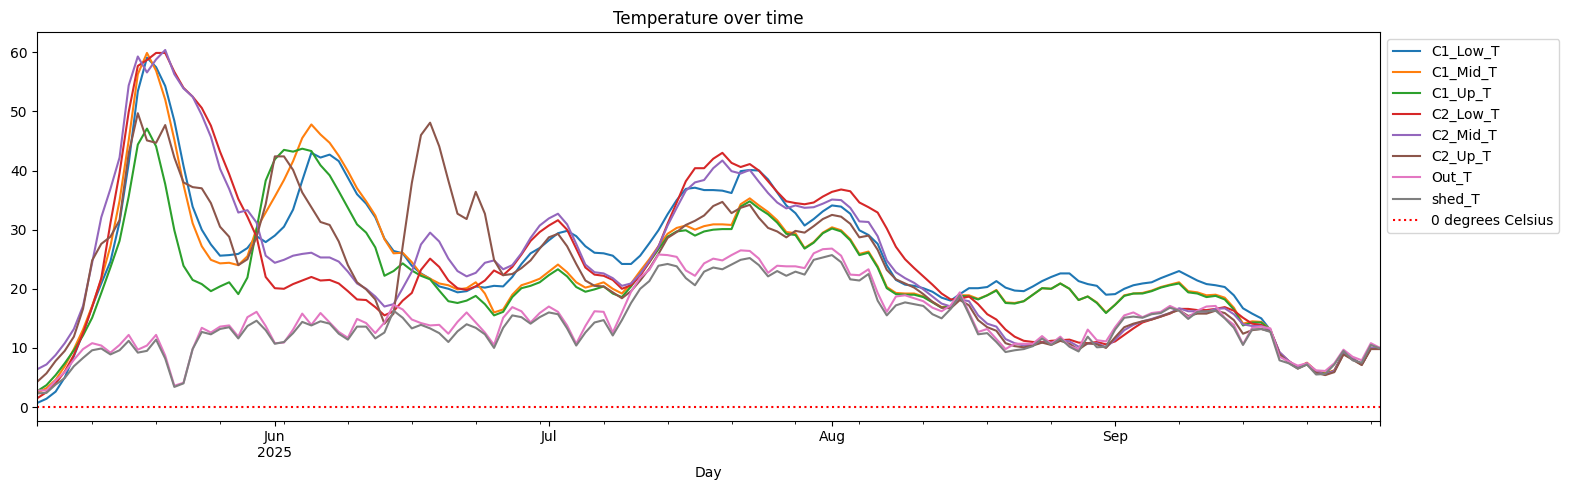

In [57]:
cols = [col for col in df.columns if col.startswith('') and col.endswith('T')]

df.set_index('Day')[cols].plot(figsize=(14, 5), title='Temperature over time')
plt.tight_layout()
plt.axhline(y=0, color='r', linestyle=':', label='0 degrees Celsius')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

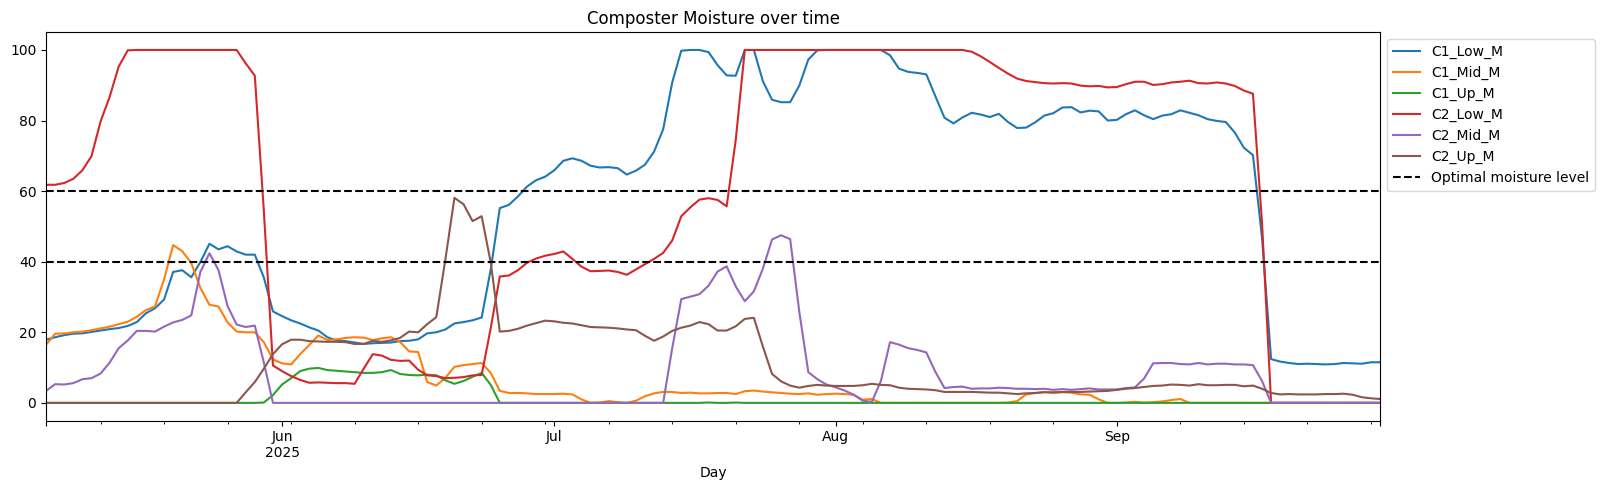

In [58]:
cols = [col for col in df.columns if col.startswith('C') and col.endswith('M')]

df.set_index('Day')[cols].plot(figsize=(14, 5), title='Composter Moisture over time')
plt.tight_layout()
plt.axhline(y=40, color='black', linestyle='--', label='Optimal moisture level')
plt.axhline(y=60, color='black', linestyle='--')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

In [59]:
df["Out_T"].min()

np.float64(2.8)

<h3><b>Results and summary:</b></h3>

Write your summary and main results here. 

<h3><b>Ideas for further improvements:</b></h3>

Write your ideas here.